In [ ]:
!pip install faiss-cpu

In [ ]:
import re
import gc
import json
from copy import deepcopy
from pathlib import Path

import faiss
import torch
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
  f1_score, precision_score, recall_score,
  accuracy_score, roc_curve, auc, roc_auc_score
)

Nesse teste, vamos utilizar uma base de observações classificadas e avaliar o comportamento de cada modelo. Para essa avaliação, utilizaremos o modelo para gerar o embedding de uma porção das observações (balanceados por classe) e utilizaremos o FAISS para realizar a busca semantica para uma nova entrada, simulando o comportamento da busca na base de conhecimento.

Como existem classes diferentes de observações, assim como, combinação entre elas, vamos avaliar segundo alguns critérios:


1.   Para as observações que apresentam apenas uma classe, o modelo deve ser capaz de gerar embeddings com qualidade o suficiente para uma nova entrada seja classificada de forma correta, com uma similaridade de pelo menos 80%.
2.   Para aquelas que apresentam mais de uma classe, teremos dois cenários distintos. O primeiro vai levar em consideração a capacidade de identificar ambas as classes com uma similaridade de pelo menos 80%. O segundo vai avaliar a capacidade de identificar pelo menos uma das classes com uma similaridade de 80%.

Para ambos os cenários, iremos variar o threshold de similaridade no intervalo de 80% - 95% com um incremento de 5%.


In [ ]:
CONFIG_PRIVATE_PATH = Path("../config/selecao_modelos.private.json")
CONFIG_EXAMPLE_PATH = Path("../config/selecao_modelos.example.json")

if CONFIG_PRIVATE_PATH.exists():
    CONFIG = json.loads(CONFIG_PRIVATE_PATH.read_text(encoding="utf-8"))
    print("Configuracao privada carregada.")
elif CONFIG_EXAMPLE_PATH.exists():
    CONFIG = json.loads(CONFIG_EXAMPLE_PATH.read_text(encoding="utf-8"))
    print("Configuracao example carregada (ajuste o private para seu ambiente).")
else:
    raise FileNotFoundError(
        "Nenhum arquivo de configuracao encontrado em ../config/selecao_modelos.*.json"
    )

def _resolve_path(path_value: str) -> Path:
    p = Path(path_value)
    return p if p.is_absolute() else (Path.cwd() / p).resolve()

input_cfg = CONFIG.get("input", {})
split_cfg = CONFIG.get("split", {})
eval_cfg = CONFIG.get("evaluation", {})
models_cfg = CONFIG.get("models", {})
execution_order = CONFIG.get("model_execution_order", [])
knowledge_base_cfg = CONFIG.get("knowledge_base", {})
reports_cfg = CONFIG.get("reports", {})

dataset_path_value = input_cfg.get("dataset_path")
text_column = input_cfg.get("text_column", "V50000000")
class_columns = input_cfg.get("class_columns", [])

assert dataset_path_value, "Configure input.dataset_path no arquivo de configuracao."
assert class_columns, "Configure input.class_columns no arquivo de configuracao."
assert text_column, "Configure input.text_column no arquivo de configuracao."
assert models_cfg, "Configure ao menos um modelo em models no arquivo de configuracao."
assert execution_order, "Configure model_execution_order no arquivo de configuracao."

DATA_PATH = _resolve_path(dataset_path_value)
assert DATA_PATH.exists(), f"Arquivo de entrada nao encontrado: {DATA_PATH}"

required_model_keys = [key for key in execution_order if key not in models_cfg]
assert not required_model_keys, f"model_execution_order possui chaves ausentes em models: {required_model_keys}"

if DATA_PATH.suffix.lower() in {".xlsx", ".xls"}:
    df = pd.read_excel(DATA_PATH, usecols=[text_column, *class_columns])
else:
    df = pd.read_csv(DATA_PATH, usecols=[text_column, *class_columns])

df['class'] = (
    df[class_columns]
      .fillna('')
      .agg(','.join, axis=1)
      .str.replace(r'^\s*,+|,+\s*$', '', regex=True)
      .str.replace(r',{2,}', ',', regex=True)
      .replace('', np.nan)
      .str.split(',')
)

if 'Contexto (Perda de Prod.)' in df.columns and 'Contexto (Baixa Prod)' in df.columns:
    df.loc[df['Contexto (Perda de Prod.)'].notna(), 'Contexto (Baixa Prod)'] = np.nan

df['qtd_class'] = df['class'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['relevante'] = df['qtd_class'].apply(lambda x: 1 if x > 0 else 0)

df[text_column] = df[text_column].astype(str).str.replace(r'[^\w\s]', '', regex=True)
df[text_column] = df[text_column].str.replace(r'\s+', ' ', regex=True).str.strip()

df.drop_duplicates(subset=[text_column], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset: {DATA_PATH}")
print(f"Total de observacoes apos limpeza: {len(df)}")
print(f"Texto alvo: {text_column}")
print(f"Classes utilizadas: {class_columns}")

In [ ]:
# Vamos avaliar o problema seguindo uma ótica binaria. Desta forma, as 
# observações passam a ser relevantes e irrelevantes
df['relevante'] = df['qtd_class'].apply(lambda x: 1 if x > 0 else 0)

In [7]:
df['relevante'].value_counts()

,count
relevante,
0,5880
1,5772


In [ ]:
knowledge_frac = float(split_cfg.get("knowledge_frac", 0.7))
random_state = int(split_cfg.get("random_state", 42))

assert 0 < knowledge_frac < 1, "split.knowledge_frac deve estar no intervalo (0, 1)."

knowledge_df = df.sample(frac=knowledge_frac, random_state=random_state).copy()
evaluation_df = df.drop(knowledge_df.index).copy()

print("Distribuicao de relevante - knowledge:")
print(knowledge_df['relevante'].value_counts())
print()
print("Distribuicao de relevante - evaluation:")
print(evaluation_df['relevante'].value_counts())

relevante
0    4083
1    4073
Name: count, dtype: int64
relevante
0    1798
1    1698
Name: count, dtype: int64


In [ ]:
THRESHOLDS = eval_cfg.get("thresholds", [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90])
BATCH_SIZE = int(eval_cfg.get("batch_size", 64))
PLOT_ROC = bool(eval_cfg.get("plot_roc", True))
PLOT_METRICS = bool(eval_cfg.get("plot_metrics", True))

def prepare_knowledge_embeddings(knowledge_df, encoding_func, encoding_func_kwargs: dict):
    knowledge_series = knowledge_df[text_column].dropna().astype(str)
    knowledge_series.reset_index(drop=True, inplace=True)
    knowledge_texts = knowledge_series.tolist()
    knowledge_ids = knowledge_series.index.to_numpy(dtype='int64')

    if len(knowledge_texts) == 0:
        raise ValueError(f"knowledge_df['{text_column}'] nao contem textos para indexar.")

    payload = deepcopy(encoding_func_kwargs)
    payload['sentences'] = knowledge_texts
    knowledge_emb = encoding_func(**payload)

    knowledge_emb = knowledge_emb.astype('float32')
    knowledge_emb /= np.linalg.norm(knowledge_emb, axis=1, keepdims=True) + 1e-12

    return knowledge_emb, knowledge_ids

def create_faiss_index(embeddings, ids):
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index = faiss.IndexIDMap(index)
    index.add_with_ids(embeddings, ids)
    return index

def evaluate_model(index, evaluation_df, encoding_func, encoding_func_kwargs: dict):
    eval_series = evaluation_df[text_column].dropna().astype(str)
    eval_texts = eval_series.tolist()
    eval_idxs = eval_series.index.to_numpy(dtype='int64')

    if len(eval_texts) == 0:
        raise ValueError(f"evaluation_df['{text_column}'] nao contem textos para busca.")

    payload = deepcopy(encoding_func_kwargs)
    payload['sentences'] = eval_texts
    eval_emb = encoding_func(**payload)
    eval_emb = eval_emb.astype('float32')
    eval_emb /= np.linalg.norm(eval_emb, axis=1, keepdims=True) + 1e-12

    k = min(1, index.ntotal)
    scores, neighbors = index.search(eval_emb, k)

    return scores, neighbors, eval_idxs

def calculate_results(scores, neighbors, eval_idxs, evaluation_df, knowledge_df, thresholds):
    results_by_threshold = {}

    for threshold in thresholds:
        rows = []
        for i, (s_row, n_row) in enumerate(zip(scores, neighbors)):
            top_score = float(s_row.max()) if s_row.size > 0 else 0.0
            matched = top_score >= threshold
            matched_id = int(n_row[s_row.argmax()]) if matched else None
            matched_relevance = knowledge_df.loc[matched_id, 'relevante'] if matched else 0
            rows.append({
                'eval_index': eval_idxs[i],
                'top_score': top_score,
                'matched': matched,
                'matched_relevance': matched_relevance
            })

        results_df = pd.DataFrame(rows)
        y_true = evaluation_df.loc[results_df['eval_index'], 'relevante']

        results_by_threshold[threshold] = {
            "f1": f1_score(y_true, results_df['matched_relevance'], zero_division=0),
            "acuracia": accuracy_score(y_true, results_df['matched_relevance']),
            "precisao": precision_score(y_true, results_df['matched_relevance'], zero_division=0),
            "recall": recall_score(y_true, results_df['matched_relevance'], zero_division=0),
            "roc_auc_score": roc_auc_score(y_true, scores[:, 0]),
        }

    return results_by_threshold

def plot_results(results: dict, title: str):
    _, ax = plt.subplots(2, 2, figsize=(12, 6))
    ax = ax.flatten()

    thresholds = list(results.keys())
    f1 = [results[t]['f1'] for t in thresholds]
    acuracia = [results[t]['acuracia'] for t in thresholds]
    precisao = [results[t]['precisao'] for t in thresholds]
    recall = [results[t]['recall'] for t in thresholds]

    ax[0].plot(thresholds, f1, marker='o')
    ax[0].set_title('F1 vs Threshold')
    ax[0].set_xlabel('Threshold')
    ax[0].set_ylabel('F1')
    ax[0].grid()

    ax[1].plot(thresholds, acuracia, marker='o')
    ax[1].set_title('Acuracia vs Threshold')
    ax[1].set_xlabel('Threshold')
    ax[1].set_ylabel('Acuracia')
    ax[1].grid()

    ax[2].plot(thresholds, precisao, marker='o')
    ax[2].set_title('Precisao vs Threshold')
    ax[2].set_xlabel('Threshold')
    ax[2].set_ylabel('Precisao')
    ax[2].grid()

    ax[3].plot(thresholds, recall, marker='o')
    ax[3].set_title('Recall vs Threshold')
    ax[3].set_xlabel('Threshold')
    ax[3].set_ylabel('Recall')
    ax[3].grid()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_true, y_probs, title='Desempenho Geral do Modelo'):
    score_vector = np.asarray(y_probs).reshape(-1)
    fpr, tpr, _ = roc_curve(y_true, score_vector)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

def run_sentence_transformer_model(model_cfg, knowledge_df, evaluation_df):
    st_kwargs = deepcopy(model_cfg.get('sentence_transformer_kwargs', {}))
    model = SentenceTransformer(model_cfg['model_name'], **st_kwargs)

    encode_method = model_cfg.get('encode_method', 'encode')
    encoder = getattr(model, encode_method)

    encoder_kwargs = deepcopy(model_cfg.get('kwargs', {}))
    encoder_kwargs.setdefault('batch_size', BATCH_SIZE)
    encoder_kwargs.setdefault('convert_to_numpy', True)

    knowledge_emb, knowledge_ids = prepare_knowledge_embeddings(knowledge_df, encoder, encoder_kwargs)
    faiss_index = create_faiss_index(knowledge_emb, knowledge_ids)
    scores, neighbors, eval_idxs = evaluate_model(faiss_index, evaluation_df, encoder, encoder_kwargs)
    results = calculate_results(scores, neighbors, eval_idxs, evaluation_df, knowledge_df, THRESHOLDS)

    label = model_cfg.get('label', model_cfg['model_name'])
    if PLOT_ROC:
        plot_roc_curve(evaluation_df['relevante'], scores[:, 0], title=f'Desempenho Geral - {label}')
    if PLOT_METRICS:
        plot_results(results, f'Metricas do Modelo - {label}')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

def encode_documents_bert(sentences, model, tokenizer, device, max_length=512, batch_size=256):
    model.eval()
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(sentences), batch_size):
            batch_docs = sentences[i:i + batch_size]
            inputs = tokenizer(
                batch_docs,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)

            attention_mask = inputs['attention_mask']
            token_embeddings = outputs.last_hidden_state
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            mean_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(
                input_mask_expanded.sum(1), min=1e-9
            )

            all_embeddings.append(mean_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

def run_bertimbau_model(model_cfg, knowledge_df, evaluation_df):
    from transformers import AutoTokenizer, AutoModel

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Usando dispositivo: {device}')

    tokenizer = AutoTokenizer.from_pretrained(model_cfg['model_name'])
    model = AutoModel.from_pretrained(model_cfg['model_name']).to(device)

    bert_kwargs = deepcopy(model_cfg.get('kwargs', {}))
    bert_kwargs.setdefault('max_length', 512)
    bert_kwargs.setdefault('batch_size', 256)

    encoder_kwargs = {
        'model': model,
        'tokenizer': tokenizer,
        'device': device,
        **bert_kwargs,
    }

    knowledge_emb, knowledge_ids = prepare_knowledge_embeddings(
        knowledge_df, encode_documents_bert, encoder_kwargs
    )
    faiss_index = create_faiss_index(knowledge_emb, knowledge_ids)
    scores, neighbors, eval_idxs = evaluate_model(
        faiss_index, evaluation_df, encode_documents_bert, encoder_kwargs
    )
    results = calculate_results(scores, neighbors, eval_idxs, evaluation_df, knowledge_df, THRESHOLDS)

    label = model_cfg.get('label', model_cfg['model_name'])
    if PLOT_ROC:
        plot_roc_curve(evaluation_df['relevante'], scores[:, 0], title=f'Desempenho Geral - {label}')
    if PLOT_METRICS:
        plot_results(results, f'Metricas do Modelo - {label}')

    del model
    del tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

def run_model_from_config(model_key, knowledge_df, evaluation_df):
    model_cfg = deepcopy(models_cfg[model_key])
    if not model_cfg.get('enabled', True):
        print(f"[SKIP] Modelo desabilitado: {model_key}")
        return None

    print(f"\n=== Avaliando modelo: {model_cfg.get('label', model_key)} ===")
    model_type = model_cfg.get('type', 'sentence_transformer')

    if model_type == 'sentence_transformer':
        return run_sentence_transformer_model(model_cfg, knowledge_df, evaluation_df)
    if model_type == 'bertimbau':
        return run_bertimbau_model(model_cfg, knowledge_df, evaluation_df)

    raise ValueError(f"Tipo de modelo nao suportado: {model_type}")

MODEL_RESULTS = {}

### [llama-embed-nemotron-8b](https://huggingface.co/nvidia/llama-embed-nemotron-8b)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

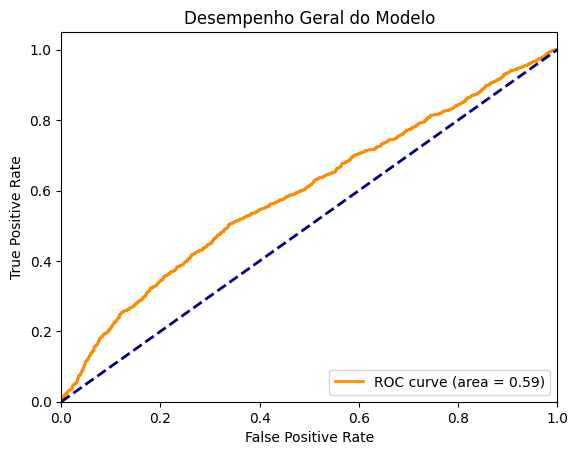

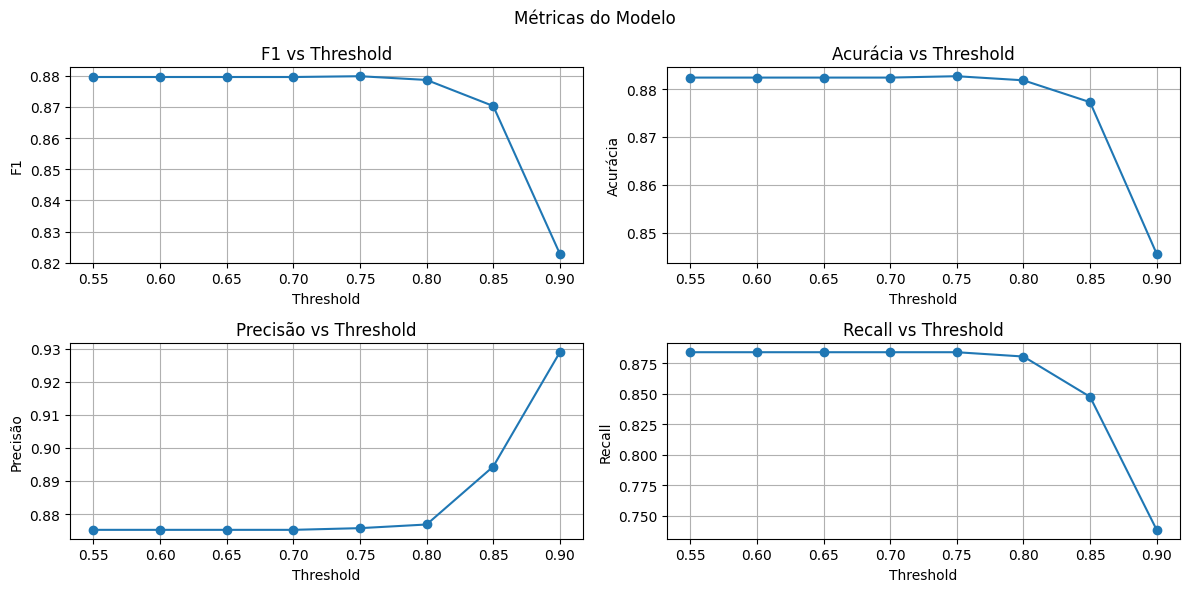

In [ ]:
MODEL_RESULTS['llama_embed_nemotron_8b'] = run_model_from_config(
    'llama_embed_nemotron_8b', knowledge_df, evaluation_df
)

### [msmarco-distilbert-cos-v5](https://huggingface.co/sentence-transformers/msmarco-distilbert-cos-v5)

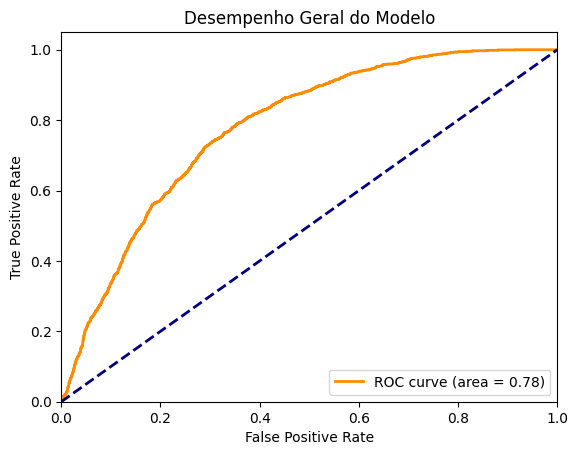

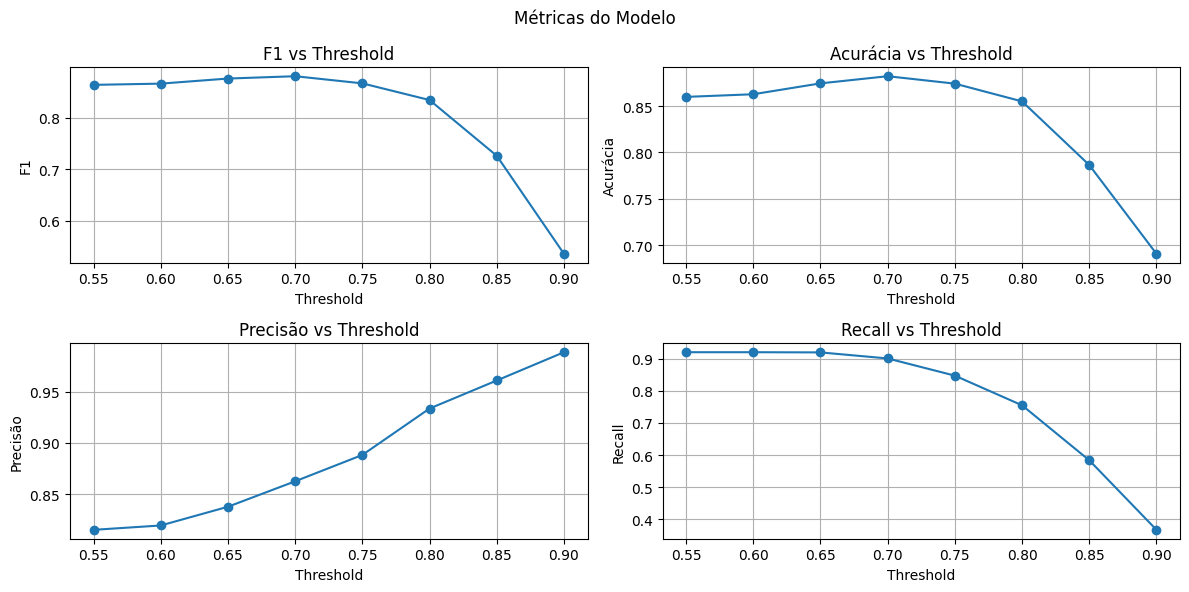

In [ ]:
MODEL_RESULTS['msmarco_distilbert_cos_v5'] = run_model_from_config(
    'msmarco_distilbert_cos_v5', knowledge_df, evaluation_df
)

### [bge-m3](https://huggingface.co/BAAI/bge-m3)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

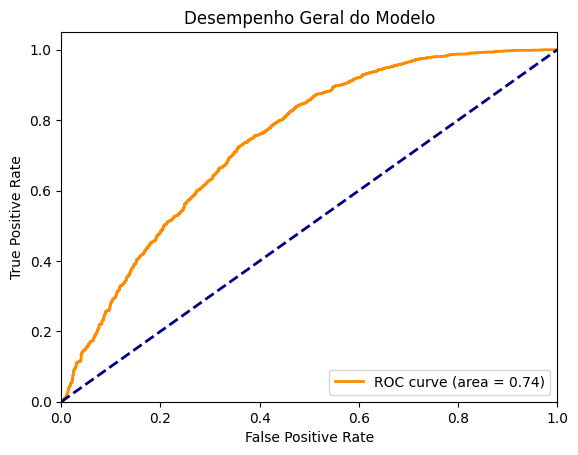

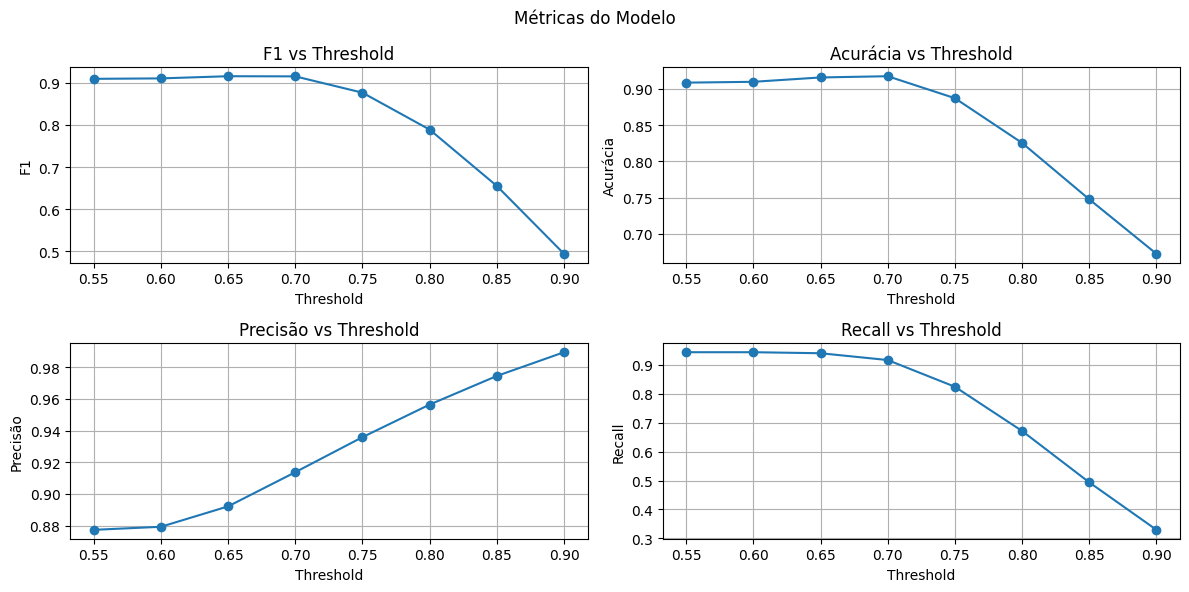

In [ ]:
MODEL_RESULTS['bge_m3'] = run_model_from_config(
    'bge_m3', knowledge_df, evaluation_df
)

### [cnmoro/portuguese-en-bge-m3](https://huggingface.co/cnmoro/portuguese-en-bge-m3)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.44G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

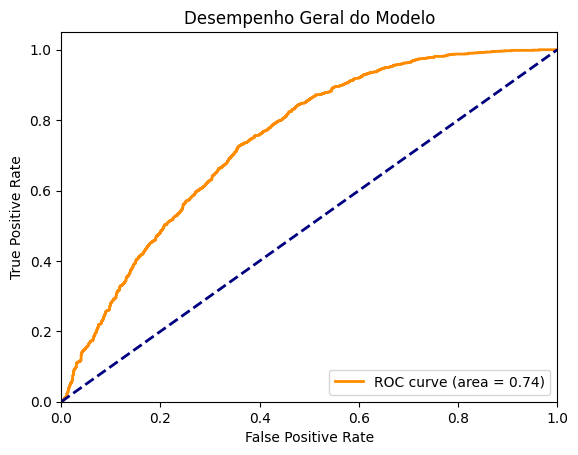

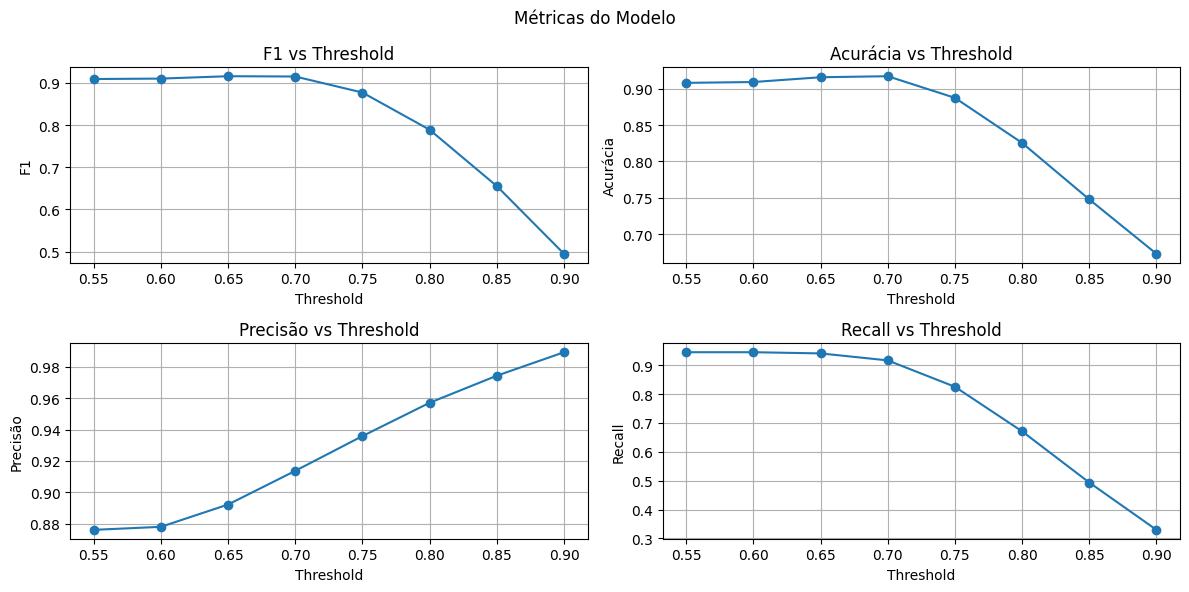

In [ ]:
MODEL_RESULTS['cnmoro_portuguese_en_bge_m3'] = run_model_from_config(
    'cnmoro_portuguese_en_bge_m3', knowledge_df, evaluation_df
)

### [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

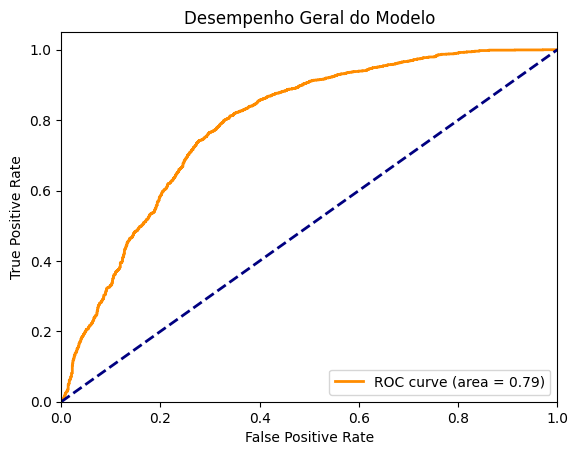

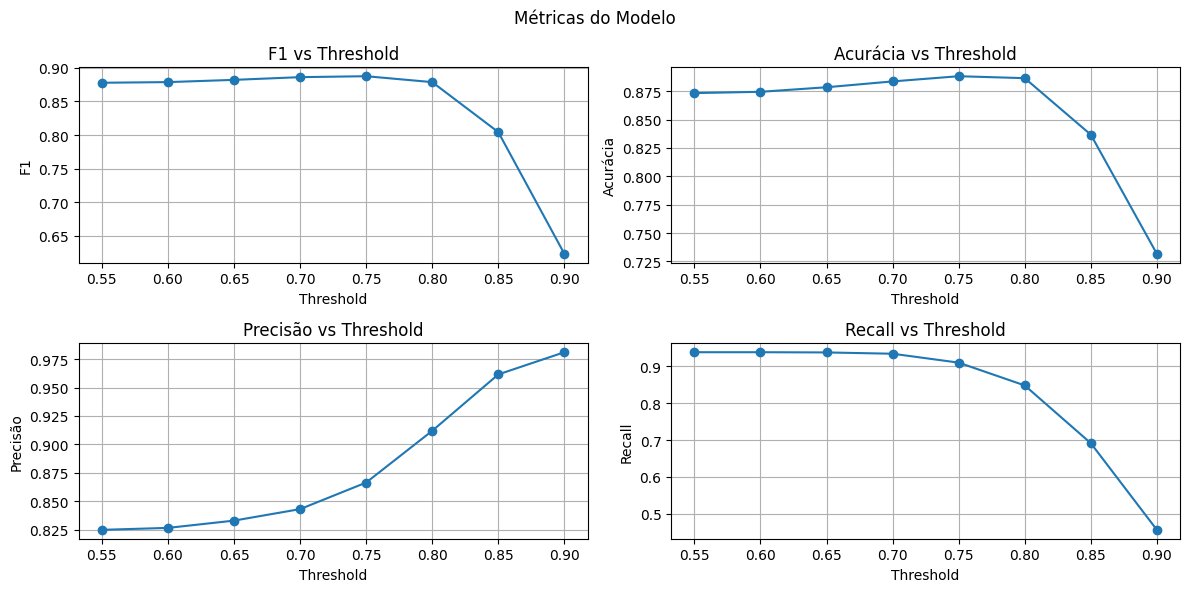

In [ ]:
MODEL_RESULTS['all_minilm_l6_v2'] = run_model_from_config(
    'all_minilm_l6_v2', knowledge_df, evaluation_df
)

### [multilingual-e5-large-instruct](https://huggingface.co/intfloat/multilingual-e5-large-instruct)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_xlm-roberta_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

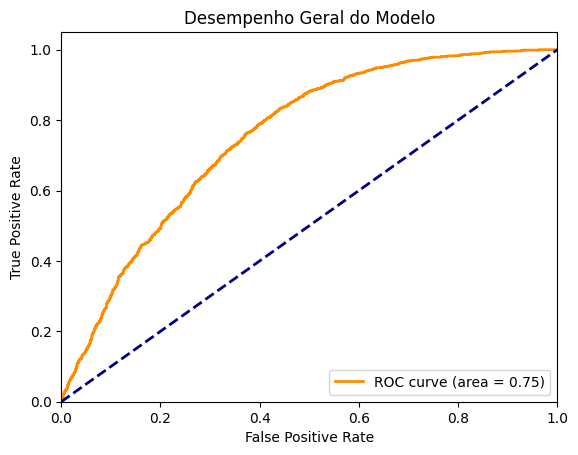

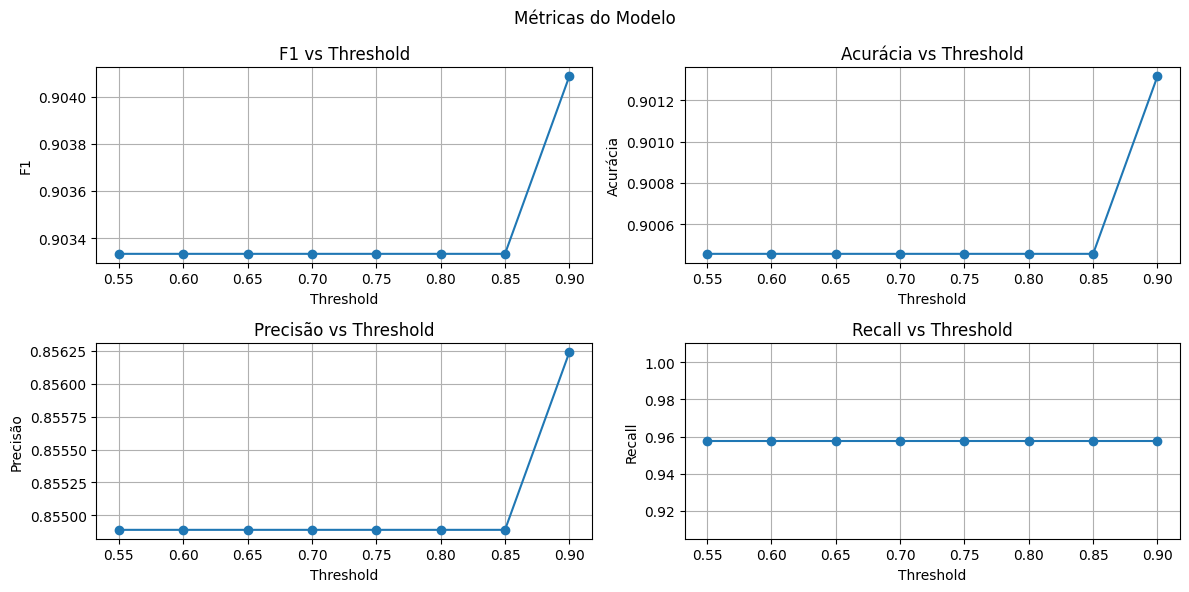

In [ ]:
MODEL_RESULTS['multilingual_e5_large_instruct'] = run_model_from_config(
    'multilingual_e5_large_instruct', knowledge_df, evaluation_df
)

### Qwen3

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

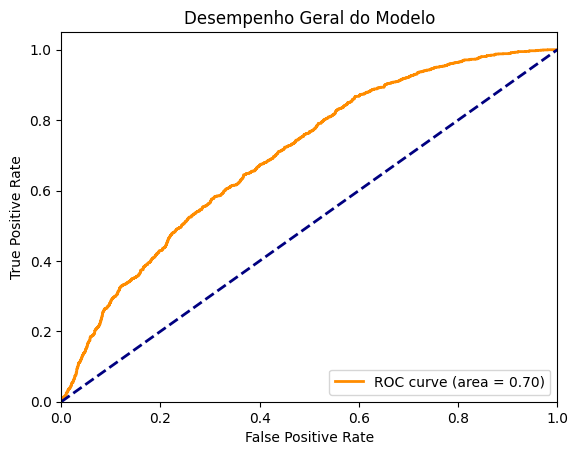

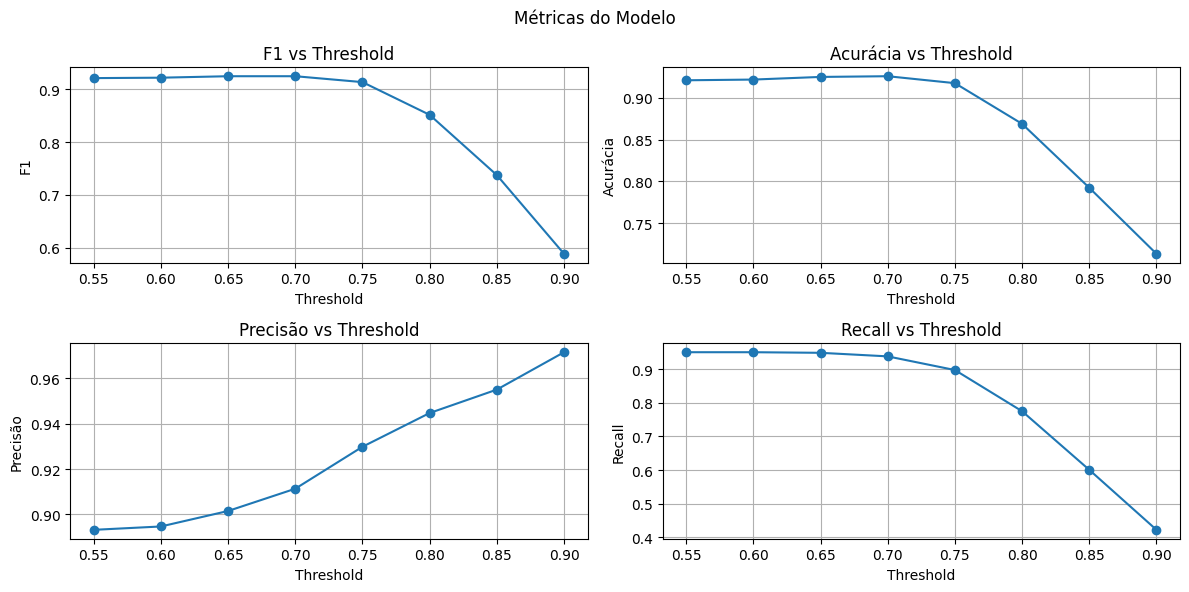

In [ ]:
MODEL_RESULTS['qwen3_embedding_8b'] = run_model_from_config(
    'qwen3_embedding_8b', knowledge_df, evaluation_df
)

### BERTIMBAU

Usando dispositivo: cuda


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

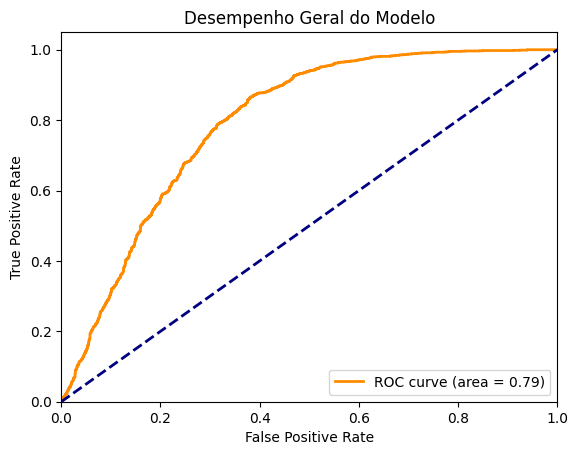

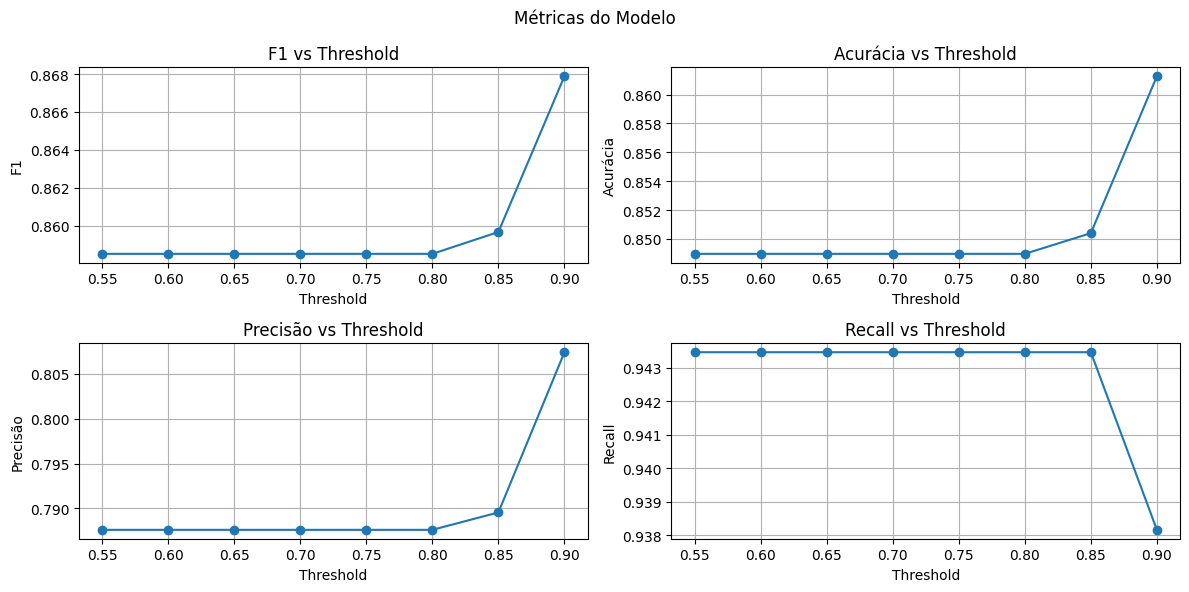

In [ ]:
MODEL_RESULTS['bertimbau'] = run_model_from_config(
    'bertimbau', knowledge_df, evaluation_df
)

# Gerando uma Base de Conhecimento

A base final em FAISS sera gerada a partir do modelo definido em `knowledge_base.model_key` no arquivo de configuracao.

In [ ]:
kb_model_key = knowledge_base_cfg.get('model_key')
assert kb_model_key, "Configure knowledge_base.model_key no arquivo de configuracao."
assert kb_model_key in models_cfg, f"Modelo da base de conhecimento nao encontrado em models: {kb_model_key}"

index_output_value = knowledge_base_cfg.get('index_output_path')
reference_output_value = knowledge_base_cfg.get('reference_output_path')
assert index_output_value, "Configure knowledge_base.index_output_path no arquivo de configuracao."
assert reference_output_value, "Configure knowledge_base.reference_output_path no arquivo de configuracao."

index_output_path = _resolve_path(index_output_value)
reference_output_path = _resolve_path(reference_output_value)
index_output_path.parent.mkdir(parents=True, exist_ok=True)
reference_output_path.parent.mkdir(parents=True, exist_ok=True)

kb_model_cfg = deepcopy(models_cfg[kb_model_key])
assert kb_model_cfg.get('type') == 'sentence_transformer', (
    "A geracao da base final atualmente suporta apenas modelos sentence_transformer."
)

model = SentenceTransformer(
    kb_model_cfg['model_name'],
    **deepcopy(kb_model_cfg.get('sentence_transformer_kwargs', {})),
)
encode_method = kb_model_cfg.get('encode_method', 'encode')
encoder = getattr(model, encode_method)
encoder_kwargs = deepcopy(kb_model_cfg.get('kwargs', {}))
encoder_kwargs.setdefault('batch_size', BATCH_SIZE)
encoder_kwargs.setdefault('convert_to_numpy', True)

knowledge_emb, knowledge_ids = prepare_knowledge_embeddings(df, encoder, encoder_kwargs)
faiss_index = create_faiss_index(knowledge_emb, knowledge_ids)

faiss.write_index(faiss_index, str(index_output_path))
df.to_csv(reference_output_path, index=False)

del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
metrics_output_value = reports_cfg.get('metrics_output_path', '../data/generated/selecao_modelos_metrics.json')
metrics_output_path = _resolve_path(metrics_output_value)
metrics_output_path.parent.mkdir(parents=True, exist_ok=True)

with metrics_output_path.open('w', encoding='utf-8') as f:
    json.dump(MODEL_RESULTS, f, ensure_ascii=False, indent=2)

print(f'Indice FAISS salvo em: {index_output_path}')
print(f'Referencia salva em: {reference_output_path}')
print(f'Metricas salvas em: {metrics_output_path}')

In [ ]:
summary_rows = []
for model_key, metrics in MODEL_RESULTS.items():
    if metrics is None or len(metrics) == 0:
        continue
    best_threshold = max(metrics, key=lambda t: metrics[t]['f1'])
    summary_rows.append({
        'model_key': model_key,
        'best_threshold': float(best_threshold),
        'best_f1': float(metrics[best_threshold]['f1']),
        'best_precision': float(metrics[best_threshold]['precisao']),
        'best_recall': float(metrics[best_threshold]['recall']),
        'best_auc': float(metrics[best_threshold]['roc_auc_score']),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('best_f1', ascending=False)
summary_df.reset_index(drop=True, inplace=True)
summary_df